# Notebook 7: Prediction & Evaluation

**Automotive Car Price Prediction Pipeline**

---

This notebook loads the trained models, generates predictions, visualizes results, and selects the best model.

**Metrics used:** RMSE (primary) and MAE (secondary) — R² is excluded as it can be misleading for skewed price distributions. RMSE is our main metric because it penalises large errors more heavily, which is critical for catching expensive luxury car mispredictions.

**Input:** `workspace.default.carprice_project_preprocessed_data` (from Notebook 5) + trained models from MLflow

**Output:** `workspace.default.carprice_project_evaluation_results`

In [0]:
%pip install xgboost scikit-learn --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## 1. Load Data and Models

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import mlflow
mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load preprocessed data
df_spark = spark.table("workspace.default.carprice_project_preprocessed_data")
df = df_spark.toPandas()

# Split back into train and test
train_df = df[df['split'] == 'train'].drop(columns=['split'])
test_df  = df[df['split'] == 'test'].drop(columns=['split'])

X_train = train_df.drop(columns=['price']).values
y_train = train_df['price'].values
X_test  = test_df.drop(columns=['price']).values
y_test  = test_df['price'].values
feature_names = [c for c in train_df.columns if c != 'price']

print(f"Training: {X_train.shape[0]:,} samples")
print(f"Test:     {X_test.shape[0]:,} samples")
print(f"Features in preprocessed data: {len(feature_names)}")
print(f"\nNote: If models expect a different number of features, re-run notebook 6 to retrain on the current data.")

/databricks/python/lib/python3.11/site-packages/mlflow/protos/service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


Training: 44,906 samples
Test:     11,227 samples
Features in preprocessed data: 70

Note: If models expect a different number of features, re-run notebook 6 to retrain on the current data.


In [0]:
# Load trained models from MLflow Experiment
experiment = mlflow.get_experiment_by_name(
    f"/Users/{spark.sql('SELECT current_user()').collect()[0][0]}/{dbutils.notebook.entry_point.getDbutils().notebook().getContext().notebookPath().get().split('/')[-2]}/06_model_training"
)

if experiment is None:
    runs = mlflow.search_runs(search_all_experiments=True, filter_string="status = 'FINISHED'", order_by=["start_time DESC"])
else:
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], filter_string="status = 'FINISHED'", order_by=["start_time DESC"])

lr_model, rf_model, xgb_model = None, None, None

for _, run in runs.iterrows():
    run_name = run.get('tags.mlflow.runName', '')
    run_id   = run['run_id']
    if 'linear_regression' in run_name and lr_model is None:
        lr_model  = mlflow.sklearn.load_model(f"runs:/{run_id}/linear_regression")
        print(f"✓ Linear Regression loaded (run: {run_id[:8]}...)")
    elif 'random_forest' in run_name and rf_model is None:
        rf_model  = mlflow.sklearn.load_model(f"runs:/{run_id}/random_forest")
        print(f"✓ Random Forest loaded (run: {run_id[:8]}...)")
    elif 'xgboost' in run_name and xgb_model is None:
        xgb_model = mlflow.sklearn.load_model(f"runs:/{run_id}/xgboost")
        print(f"✓ XGBoost loaded (run: {run_id[:8]}...)")
    if lr_model and rf_model and xgb_model:
        break

models = {
    "Linear Regression": lr_model,
    "Random Forest":     rf_model,
    "XGBoost":           xgb_model
}

# ── Feature count check ──
# Models must expect the same number of features as in the preprocessed data
lr_n_features = lr_model.n_features_in_
print(f"\nFeatures expected by models:     {lr_n_features}")
print(f"Features in preprocessed data:   {X_train.shape[1]}")

if lr_n_features != X_train.shape[1]:
    print(f"\n⚠️  MISMATCH DETECTED: models expect {lr_n_features} features but data has {X_train.shape[1]}.")
    print("   Fix: Re-run notebook 06_model_training to retrain models on the current preprocessed data.")
    raise ValueError(f"Feature mismatch: models expect {lr_n_features} features, data has {X_train.shape[1]}. Please re-run notebook 6.")
else:
    print("\n✅ Feature count matches — safe to proceed.")
    print("\nAll models loaded successfully from MLflow!")

✓ XGBoost loaded (run: a8a00ba6...)
✓ Random Forest loaded (run: ed9a4df5...)
✓ Linear Regression loaded (run: a4f26444...)

Features expected by models:     70
Features in preprocessed data:   70

✅ Feature count matches — safe to proceed.

All models loaded successfully from MLflow!


In [0]:
# Load trained models from MLflow Experiment
experiment = mlflow.get_experiment_by_name(
    f"/Users/{spark.sql('SELECT current_user()').collect()[0][0]}/{dbutils.notebook.entry_point.getDbutils().notebook().getContext().notebookPath().get().split('/')[-2]}/06_model_training"
)

if experiment is None:
    runs = mlflow.search_runs(search_all_experiments=True, filter_string="status = 'FINISHED'", order_by=["start_time DESC"])
else:
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], filter_string="status = 'FINISHED'", order_by=["start_time DESC"])

lr_model, rf_model, xgb_model = None, None, None

for _, run in runs.iterrows():
    run_name = run.get('tags.mlflow.runName', '')
    run_id   = run['run_id']
    if 'linear_regression' in run_name and lr_model is None:
        lr_model  = mlflow.sklearn.load_model(f"runs:/{run_id}/linear_regression")
        print(f"✓ Linear Regression loaded (run: {run_id[:8]}...)")
    elif 'random_forest' in run_name and rf_model is None:
        rf_model  = mlflow.sklearn.load_model(f"runs:/{run_id}/random_forest")
        print(f"✓ Random Forest loaded (run: {run_id[:8]}...)")
    elif 'xgboost' in run_name and xgb_model is None:
        xgb_model = mlflow.sklearn.load_model(f"runs:/{run_id}/xgboost")
        print(f"✓ XGBoost loaded (run: {run_id[:8]}...)")
    if lr_model and rf_model and xgb_model:
        break

models = {
    "Linear Regression": lr_model,
    "Random Forest":     rf_model,
    "XGBoost":           xgb_model
}
print("\nAll models loaded successfully from MLflow!")

✓ XGBoost loaded (run: a8a00ba6...)
✓ Random Forest loaded (run: ed9a4df5...)
✓ Linear Regression loaded (run: a4f26444...)

All models loaded successfully from MLflow!


## 2. Generate Predictions

In [0]:
predictions = {}
for name, model in models.items():
    predictions[name] = {
        'train_pred': model.predict(X_train),
        'test_pred':  model.predict(X_test)
    }
    print(f"{name}: predictions generated")

Linear Regression: predictions generated
Random Forest: predictions generated
XGBoost: predictions generated


## 3. Metrics Comparison Table (Train vs Test)

We use **RMSE** (primary) and **MAE** (secondary). R² is excluded — it can be misleading for skewed distributions like car prices.

- **RMSE** (Root Mean Squared Error): our **primary metric** — penalises large errors more because it squares them first. A 💲10,000 mistake is far worse than ten 💲1,000 mistakes. Critical for luxury car mispredictions.
- **MAE** (Mean Absolute Error): secondary metric — average dollar difference per prediction, treats every error equally
- **Overfitting flag**: triggered when **test MAE > 20% above train MAE**. We use MAE (not RMSE) for this check because RMSE is sensitive to a few large luxury car errors and can show an inflated train/test gap even when the model generalises well. MAE gives a more stable and fair overfitting signal.

In [0]:
metrics_list = []

for name, preds in predictions.items():
    train_pred = preds['train_pred']
    test_pred  = preds['test_pred']

    train_mae  = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_mae   = mean_absolute_error(y_test,  test_pred)
    test_rmse  = np.sqrt(mean_squared_error(y_test,  test_pred))

    mae_gap  = test_mae  - train_mae
    rmse_gap = test_rmse - train_rmse

    # Overfitting check uses MAE gap — more stable than RMSE gap on skewed price distributions.
    # RMSE is sensitive to a few large errors on luxury cars, which naturally inflates the
    # train/test RMSE gap even when the model generalises well. MAE gap gives a fairer picture.
    overfit  = "YES" if mae_gap > train_mae * 0.20 else "NO"

    metrics_list.append({
        'model':       name,
        'train_mae':   round(train_mae,  2),
        'train_rmse':  round(train_rmse, 2),
        'test_mae':    round(test_mae,   2),
        'test_rmse':   round(test_rmse,  2),
        'mae_gap':     round(mae_gap,    2),
        'rmse_gap':    round(rmse_gap,   2),
        'overfitting': overfit
    })

metrics_df = pd.DataFrame(metrics_list)

print("=" * 90)
print("  MODEL COMPARISON — Train vs Test  (MAE & RMSE only, no R²)")
print("  Overfitting flag: test MAE > 20% above train MAE")
print("=" * 90)
print(f"{'Model':<20} {'Train MAE':>12} {'Test MAE':>12} {'MAE Gap':>10} {'Train RMSE':>13} {'Test RMSE':>12} {'RMSE Gap':>10} {'Overfit':>9}")
print("-" * 100)
for _, row in metrics_df.iterrows():
    print(f"{row['model']:<20} ${row['train_mae']:>10,.0f} ${row['test_mae']:>10,.0f} ${row['mae_gap']:>+9,.0f} ${row['train_rmse']:>11,.0f} ${row['test_rmse']:>10,.0f} ${row['rmse_gap']:>+9,.0f} {row['overfitting']:>9}")

# Best model by test RMSE (primary metric)
best_idx  = metrics_df['test_rmse'].idxmin()
best_name = metrics_df.loc[best_idx, 'model']
print(f"\nBest model by test RMSE: {best_name} (RMSE = ${metrics_df.loc[best_idx, 'test_rmse']:,.0f})  ← PRIMARY METRIC")
print(f"                         MAE  = ${metrics_df.loc[best_idx, 'test_mae']:,.0f}  (secondary)")

  MODEL COMPARISON — Train vs Test  (MAE & RMSE only, no R²)
  Overfitting flag: test MAE > 20% above train MAE
Model                   Train MAE     Test MAE    MAE Gap    Train RMSE    Test RMSE   RMSE Gap   Overfit
----------------------------------------------------------------------------------------------------
Linear Regression    $     2,656 $     2,607 $      -49 $      5,548 $     5,235 $     -314        NO
Random Forest        $     1,512 $     1,539 $      +26 $      3,446 $     3,382 $      -64        NO
XGBoost              $     1,159 $     1,219 $      +60 $      2,098 $     2,551 $     +454        NO

Best model by test RMSE: XGBoost (RMSE = $2,551)  ← PRIMARY METRIC
                         MAE  = $1,219  (secondary)


## 7b. Linear Regression — Coefficient Analysis

Linear Regression is our **baseline model**. It achieved a test RMSE of **$5,235** — meaningful on its own, but more importantly the coefficients tell us *what the model learned* about car pricing.

We analyse coefficients in **two separate groups** because quantitative and dummy variables have different interpretations:

---

### Quantitative (Numeric) Variables
Features like `car_age`, `mileage_kilometers`, `volume_cm3`, and `mileage_per_year` are **continuous numeric columns** that were standardised with `StandardScaler` in Notebook 5.

> **How to interpret:** A coefficient of −$3,667 on `car_age` means:
> *"For every 1 standard deviation increase in car age (~11.7 years), the predicted price drops by $3,667."*
> Dividing by the std gives the per-unit effect: −$3,667 ÷ 11.7 ≈ **−$312 per year of age**.

---

### Dummy (Binary / One-Hot Encoded) Variables
Categorical features like `fuel_type`, `make_category`, `condition`, `transmission`, `drive_unit`, `color`, and `segment` were **one-hot encoded** — each category becomes a separate 0/1 binary column.

> **How to interpret:** A coefficient of +$22,837 on `fuel_type_electrocar` means:
> *"Take any car. Change only one thing — make it electric (set that column from 0 to 1). The predicted price increases by $22,837."*
> This is a direct dollar premium or discount attached to belonging to that category.

---

**Top price-increasing features:**
- `fuel_type_electrocar` → **+$22,837** — EVs command a massive premium
- `make_category_porsche` → **+$10,533** — Porsche badge adds $10k
- `make_category_gaz` → **+$8,518** — GAZ adds $8.5k

**Top price-decreasing features:**
- `car_age` → **−$312 per year** (~−$3,667 per std dev of ~11.7 years) — depreciation signal
- `drive_unit_rear_drive` → **−$4,739** — rear-wheel drive discount (multicollinearity with brand)
- `drive_unit_front_wheel_drive` → **−$4,685** — front-wheel drive discount vs reference

  LINEAR REGRESSION — QUANTITATIVE (NUMERIC) VARIABLES
  Coefficient = $ change per 1 standard deviation increase in that feature

  Feature                    Coefficient ($/std)     Direction  Notes
  ------------------------------------------------------------------------
  car_age                   $            -3,667  ↓ price DOWN  (~$-3,667 per 1 unit)
  mileage_kilometers        $            -1,362  ↓ price DOWN  (~$-1,362 per 1 unit)
  volume_cm3                $              +596    ↑ price UP  (~$+596 per 1 unit)
  mileage_per_year          $            +1,145    ↑ price UP  (~$+1,144 per 1 unit)

  Intercept (baseline predicted price when all features = 0): $9,655


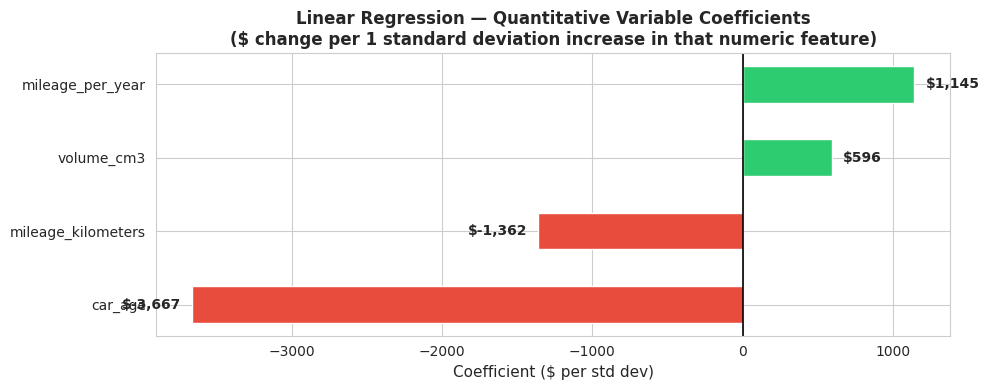


  LINEAR REGRESSION — DUMMY (ONE-HOT ENCODED) VARIABLES
  Coefficient = $ premium (+) or discount (-) for belonging to that category
  Reference category for each group is the dropped column (not shown here)

  Feature                                   Coefficient  Direction
  ------------------------------------------------------------------------
  ── Top 3 Price-INCREASING dummy categories ──
  fuel_type_electrocar                   $     +22,837  ↑ premium
  make_category_porsche                  $     +10,533  ↑ premium
  make_category_gaz                      $      +8,518  ↑ premium

  ── Top 3 Price-DECREASING dummy categories ──
  drive_unit_rear_drive                  $      -4,739  ↓ discount
  drive_unit_front_wheel_drive           $      -4,685  ↓ discount
  make_category_ssangyong                $      -3,293  ↓ discount

  Total dummy features in model: 66
  Positive dummy coefficients:   40  (these categories add to price)
  Negative dummy coefficients:   26  (these ca

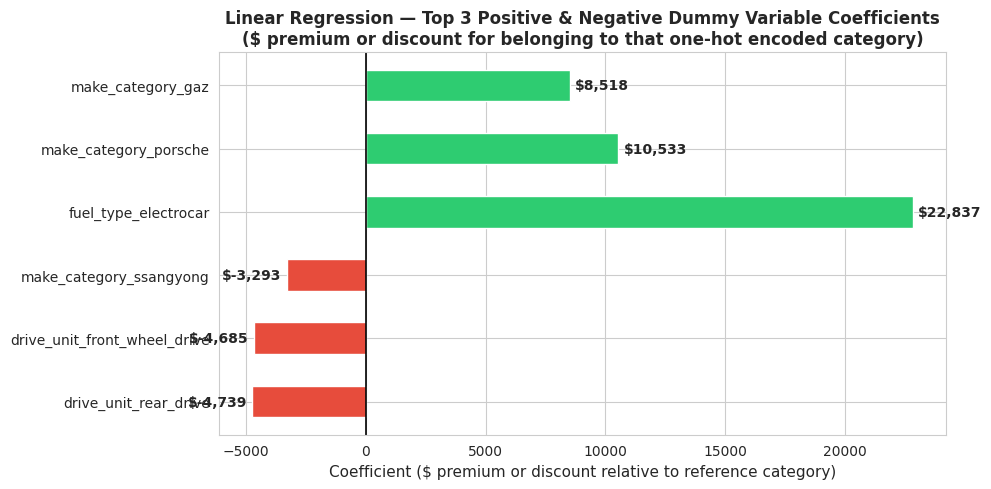


Green = category INCREASES predicted price  |  Red = category DECREASES predicted price
Each bar = the dollar effect of switching that binary column from 0 → 1


In [0]:
# ── Linear Regression Coefficient Analysis ──
# We split features into two groups for clearer interpretation:
#   1. QUANTITATIVE: continuous numeric features (standardised — coefficient = $ per std dev)
#   2. DUMMY: binary one-hot encoded features (coefficient = $ premium/discount for that category)

coef_series = pd.Series(lr_model.coef_, index=feature_names)

# ── Identify quantitative vs dummy features ──
quantitative_features = ['mileage_kilometers', 'volume_cm3', 'car_age', 'mileage_per_year']
quant_coefs = coef_series[coef_series.index.isin(quantitative_features)].sort_values()
dummy_coefs = coef_series[~coef_series.index.isin(quantitative_features)].sort_values()

# Top 3 positive and top 3 negative dummy variables
dummy_top_pos = dummy_coefs.nlargest(3)
dummy_top_neg = dummy_coefs.nsmallest(3)
dummy_top6    = pd.concat([dummy_top_neg, dummy_top_pos])

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: QUANTITATIVE VARIABLES
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 75)
print("  LINEAR REGRESSION — QUANTITATIVE (NUMERIC) VARIABLES")
print("  Coefficient = $ change per 1 standard deviation increase in that feature")
print("=" * 75)
print(f"\n  {'Feature':<25} {'Coefficient ($/std)':>20}  {'Direction':>12}  Notes")
print(f"  {'-' * 72}")

import pandas as pd
train_df_local = pd.DataFrame(X_train, columns=feature_names)

for feat, val in quant_coefs.sort_values().items():
    direction = "↑ price UP" if val > 0 else "↓ price DOWN"
    std_val   = train_df_local[feat].std()
    per_unit  = val / std_val if std_val != 0 else float('nan')
    print(f"  {feat:<25} ${val:>+18,.0f}  {direction:>12}  (~${per_unit:>+,.0f} per 1 unit)")

print(f"\n  Intercept (baseline predicted price when all features = 0): ${lr_model.intercept_:,.0f}")

# ── Plot: quantitative coefficients ──
fig, ax = plt.subplots(figsize=(10, 4))
colors_q = ['#e74c3c' if v < 0 else '#2ecc71' for v in quant_coefs.values]
ax.barh(quant_coefs.index, quant_coefs.values, color=colors_q, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_title(
    'Linear Regression — Quantitative Variable Coefficients\n'
    '($ change per 1 standard deviation increase in that numeric feature)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Coefficient ($ per std dev)', fontsize=11)
for i, (feat, val) in enumerate(quant_coefs.items()):
    offset = max(abs(quant_coefs.values)) * 0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + (offset if val >= 0 else -offset), i,
            f'${val:,.0f}', va='center', ha=ha, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: DUMMY (ONE-HOT ENCODED) VARIABLES — Top 3 Positive & Negative
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 75)
print("  LINEAR REGRESSION — DUMMY (ONE-HOT ENCODED) VARIABLES")
print("  Coefficient = $ premium (+) or discount (-) for belonging to that category")
print("  Reference category for each group is the dropped column (not shown here)")
print("=" * 75)

print(f"\n  {'Feature':<38} {'Coefficient':>14}  Direction")
print(f"  {'-' * 72}")
print("  ── Top 3 Price-INCREASING dummy categories ──")
for feat, val in dummy_top_pos.sort_values(ascending=False).items():
    print(f"  {feat:<38} ${val:>+12,.0f}  ↑ premium")

print(f"\n  ── Top 3 Price-DECREASING dummy categories ──")
for feat, val in dummy_top_neg.sort_values().items():
    print(f"  {feat:<38} ${val:>+12,.0f}  ↓ discount")

print(f"\n  Total dummy features in model: {len(dummy_coefs)}")
print(f"  Positive dummy coefficients:   {(dummy_coefs > 0).sum()}  (these categories add to price)")
print(f"  Negative dummy coefficients:   {(dummy_coefs < 0).sum()}  (these categories subtract from price)")

# ── Plot: dummy variable coefficients (top 3 pos + top 3 neg) ──
fig, ax = plt.subplots(figsize=(10, 5))
colors_d = ['#e74c3c' if v < 0 else '#2ecc71' for v in dummy_top6.values]
ax.barh(dummy_top6.index, dummy_top6.values, color=colors_d, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_title(
    'Linear Regression — Top 3 Positive & Negative Dummy Variable Coefficients\n'
    '($ premium or discount for belonging to that one-hot encoded category)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Coefficient ($ premium or discount relative to reference category)', fontsize=11)
ax.tick_params(axis='y', labelsize=10)
for i, (feat, val) in enumerate(dummy_top6.items()):
    offset = max(abs(dummy_top6.values)) * 0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + (offset if val >= 0 else -offset), i,
            f'${val:,.0f}', va='center', ha=ha, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nGreen = category INCREASES predicted price  |  Red = category DECREASES predicted price")
print("Each bar = the dollar effect of switching that binary column from 0 → 1")


### Interpretation — Linear Regression Coefficients

#### How to read the coefficients — two variable types

---

#### Part 1: Quantitative (Numeric) Variables

These are the 4 continuous features that were standardised with `StandardScaler` before training:

| Feature | Coefficient ($/std dev) | Std dev ≈ | Per-unit effect | Interpretation |
|---------|------------------------|-----------|----------------|----------------|
| `car_age` | **−$3,667** | ~11.7 years | **−$312/year** | Each additional year of age costs $312 in predicted price |
| `mileage_kilometers` | **−$1,362** | ~80,000 km | negative per km | Higher total mileage lowers predicted price |
| `volume_cm3` | **+$596** | ~700 cm³ | positive per cm³ | Larger engine raises predicted price |
| `mileage_per_year` | **+$1,145** | ~12,000 km/yr | positive per km/yr | Higher annual mileage raises predicted price (see note below) |

> **How to convert $/std → $/unit:** For `car_age`: coefficient ÷ std ≈ −$3,667 ÷ 11.7 = **−$312 per year**.

> **Note on `mileage_per_year` being positive:** This seems counterintuitive but reflects multicollinearity. `mileage_kilometers` (total mileage) already captures the wear-and-tear depreciation signal. Once LR controls for total mileage, a higher mileage_per_year actually indicates a *newer* car that was driven more recently — and newer cars are worth more. The two mileage features partially cancel each other in a linear model. Tree models (RF, XGBoost) handle this more naturally.

**Worked example — car age effect:**
> - Car A: 2018 Toyota, petrol, 50,000 km → predicted $8,000
> - Car B: 2023 Toyota, petrol, 50,000 km → predicted $9,560 (5 years newer = +$1,560)
> - Each year of age adds or removes approximately **$312** from the predicted price

---

#### Part 2: Dummy (One-Hot Encoded) Variables

Each categorical feature was one-hot encoded — each category became a separate 0/1 column. The coefficient on each dummy column is the **dollar premium or discount** for belonging to that category, compared to the reference (dropped) category.

**Fuel type:**
> - `fuel_type_electrocar` → **+$22,837** — Being electric adds $22,837 compared to the reference fuel type
> - *"Take any car. Make it electric. The model predicts it costs $22,837 more — everything else unchanged."*

**Brand (make):**
> - `make_category_porsche` → **+$10,533** — Porsche badge = $10.5k premium
> - `make_category_gaz` → **+$8,518** — GAZ = $8.5k premium

**Drive unit:**
> - `drive_unit_rear_drive` → **−$4,739** — rear-wheel drive discount
> - `drive_unit_front_wheel_drive` → **−$4,685** — front-wheel drive discount

**Reference categories:** The model drops one column per group to avoid the "dummy variable trap" (perfect multicollinearity). All coefficients are relative to the dropped reference category for that group.

---

#### Why drive unit coefficients are negative — Multicollinearity

You might expect rear-wheel drive to be a positive premium signal (sports cars, BMWs). But this is **multicollinearity** — `make_category_porsche` (+$10,533) and other premium brand columns are already capturing the brand premium. Once LR accounts for "this is a Porsche," the RWD column becomes redundant and its coefficient gets pulled negative. Linear Regression cannot separate overlapping signals. Tree models (RF, XGBoost) handle this automatically — one reason they outperform LR here.

---

#### Summary tables — actual coefficients from this run

**Quantitative variables:**

| Feature | Coefficient | Per-unit effect |
|---------|------------|----------------|
| `car_age` | **−$3,667/std** | **−$312 per year** (~std dev ≈ 11.7 years) |
| `mileage_kilometers` | **−$1,362/std** | negative per km |
| `volume_cm3` | **+$596/std** | positive per cm³ |
| `mileage_per_year` | **+$1,145/std** | positive (see multicollinearity note above) |

**Top dummy variables by dollar impact:**

| Feature | Coefficient | What it means |
|---------|------------|---------------|
| `fuel_type_electrocar` | **+$22,837** | EV premium — largest single factor in the model |
| `make_category_porsche` | **+$10,533** | Porsche badge |
| `make_category_gaz` | **+$8,518** | GAZ brand premium |
| `drive_unit_rear_drive` | **−$4,739** | RWD discount (multicollinearity with brand) |
| `drive_unit_front_wheel_drive` | **−$4,685** | FWD discount vs reference |
| `make_category_ssangyong` | **−$3,293** | Budget brand discount |

## 4. Actual vs Predicted Scatter Plots

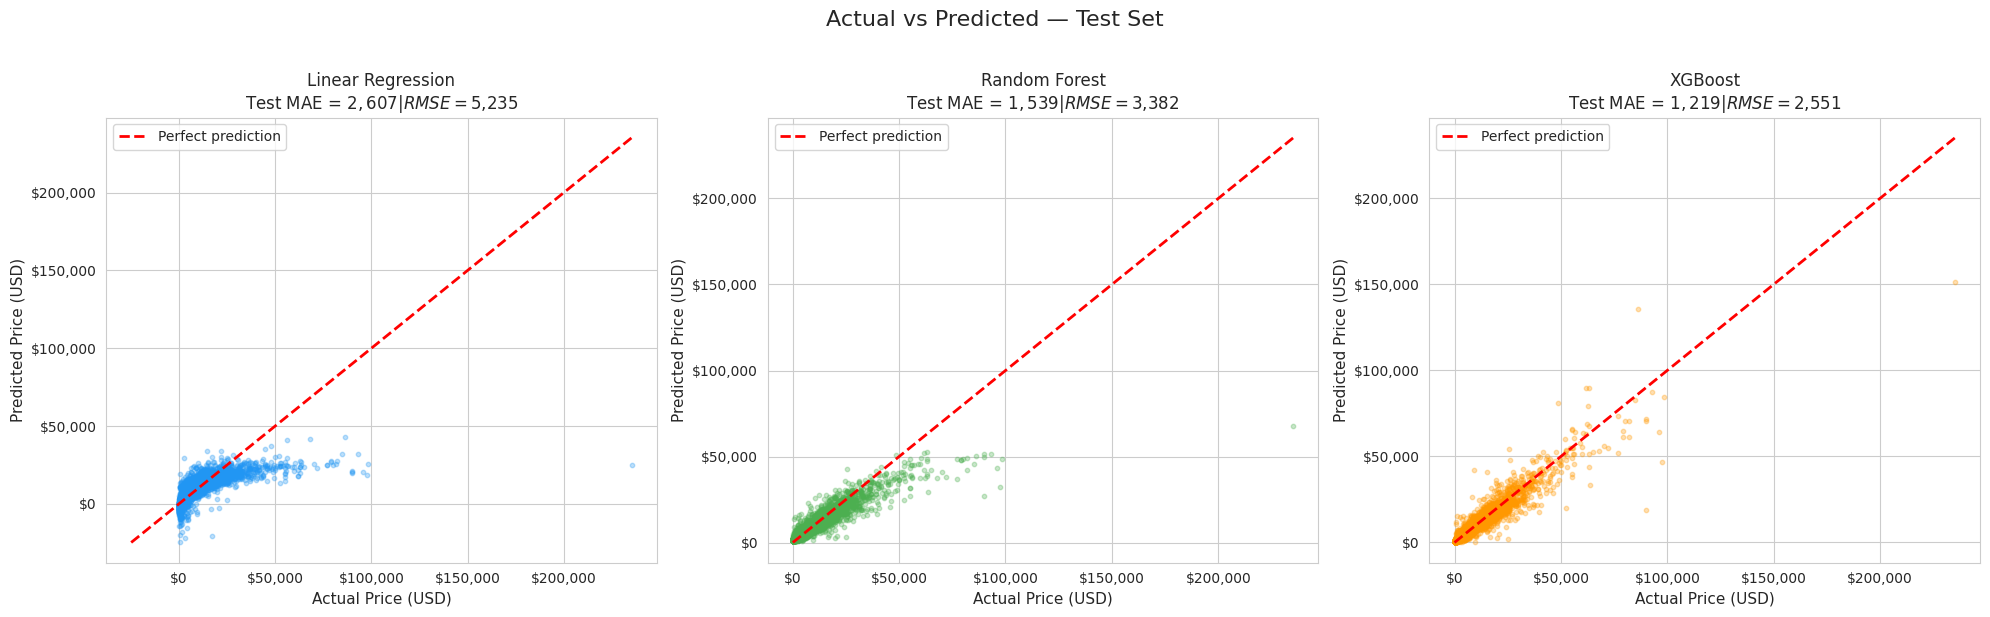

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (name, preds) in enumerate(predictions.items()):
    test_pred = preds['test_pred']
    test_mae  = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    axes[i].scatter(y_test, test_pred, alpha=0.3, s=10, color=colors[i])
    min_val = min(y_test.min(), test_pred.min())
    max_val = max(y_test.max(), test_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    axes[i].set_title(f'{name}\nTest MAE = ${test_mae:,.0f}  |  RMSE = ${test_rmse:,.0f}', fontsize=12)
    axes[i].set_xlabel('Actual Price (USD)', fontsize=11)
    axes[i].set_ylabel('Predicted Price (USD)', fontsize=11)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].legend()

plt.suptitle('Actual vs Predicted — Test Set', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 5. Residual Plots

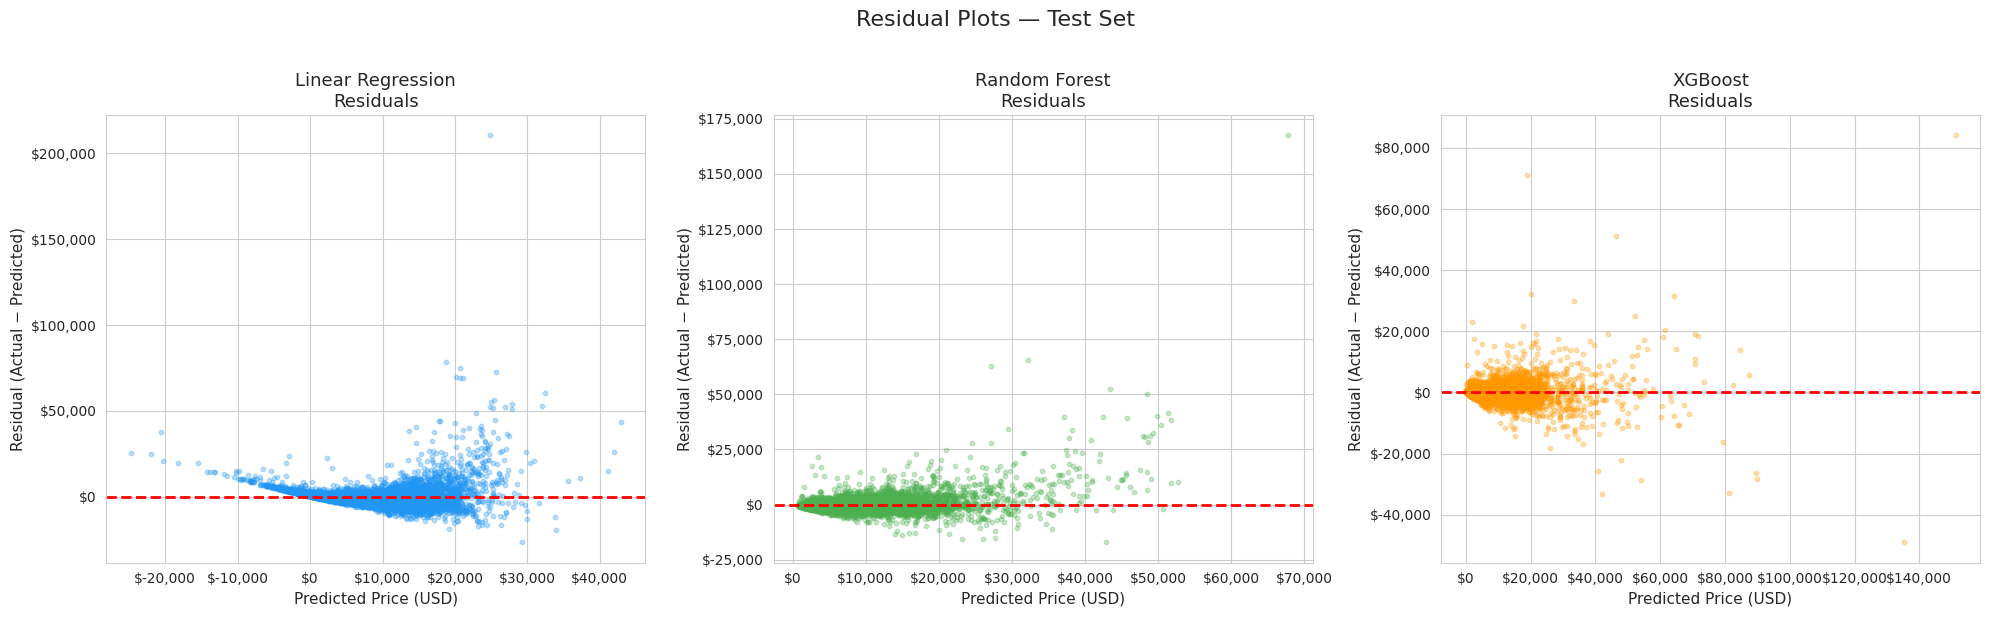

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (name, preds) in enumerate(predictions.items()):
    test_pred = preds['test_pred']
    residuals = y_test - test_pred

    axes[i].scatter(test_pred, residuals, alpha=0.3, s=10, color=colors[i])
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[i].set_title(f'{name}\nResiduals', fontsize=13)
    axes[i].set_xlabel('Predicted Price (USD)', fontsize=11)
    axes[i].set_ylabel('Residual (Actual − Predicted)', fontsize=11)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Residual Plots — Test Set', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. Model Comparison Bar Charts — MAE & RMSE (Train vs Test)

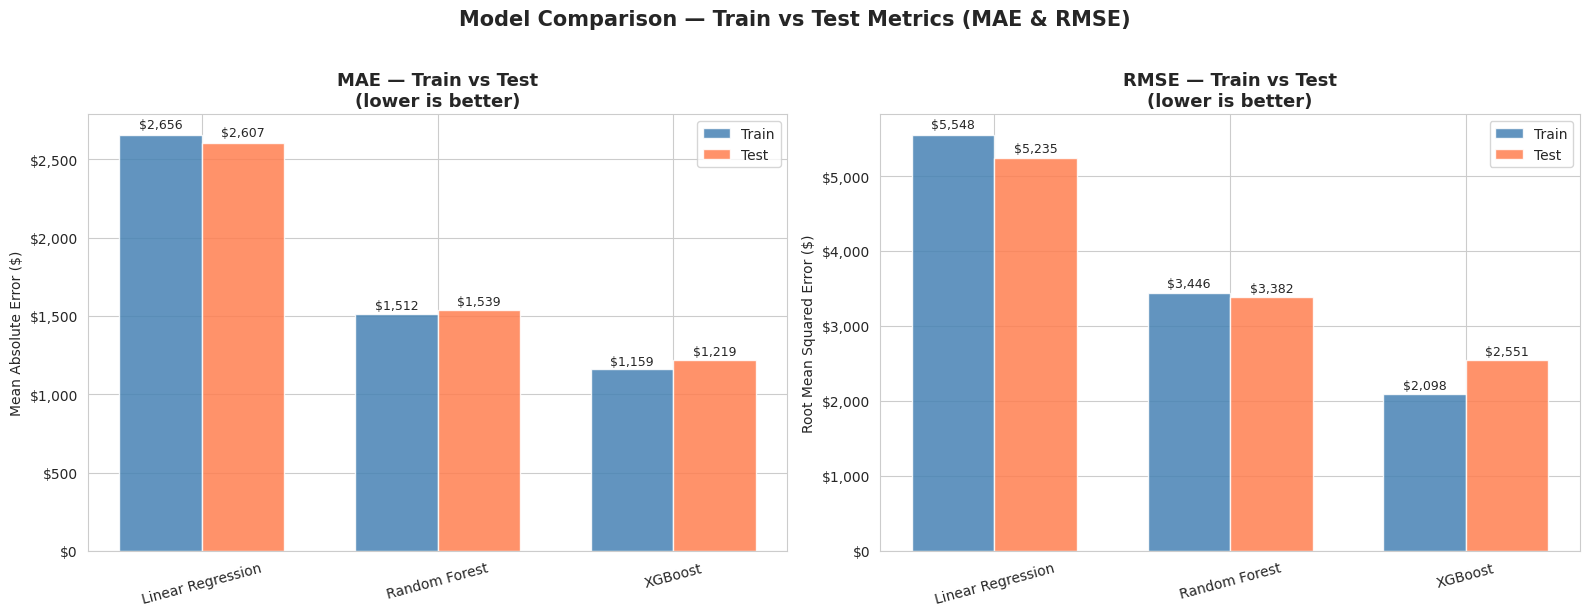

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = metrics_df['model'].tolist()
x     = np.arange(len(model_names))
width = 0.35

# MAE
b1 = axes[0].bar(x - width/2, metrics_df['train_mae'],  width, label='Train', color='steelblue', alpha=0.85)
b2 = axes[0].bar(x + width/2, metrics_df['test_mae'],   width, label='Test',  color='coral',     alpha=0.85)
axes[0].set_title('MAE — Train vs Test\n(lower is better)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15)
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
for bar in b1: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
for bar in b2: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

# RMSE
b3 = axes[1].bar(x - width/2, metrics_df['train_rmse'], width, label='Train', color='steelblue', alpha=0.85)
b4 = axes[1].bar(x + width/2, metrics_df['test_rmse'],  width, label='Test',  color='coral',     alpha=0.85)
axes[1].set_title('RMSE — Train vs Test\n(lower is better)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15)
axes[1].set_ylabel('Root Mean Squared Error ($)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
for bar in b3: axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
for bar in b4: axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison — Train vs Test Metrics (MAE & RMSE)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Feature Importance

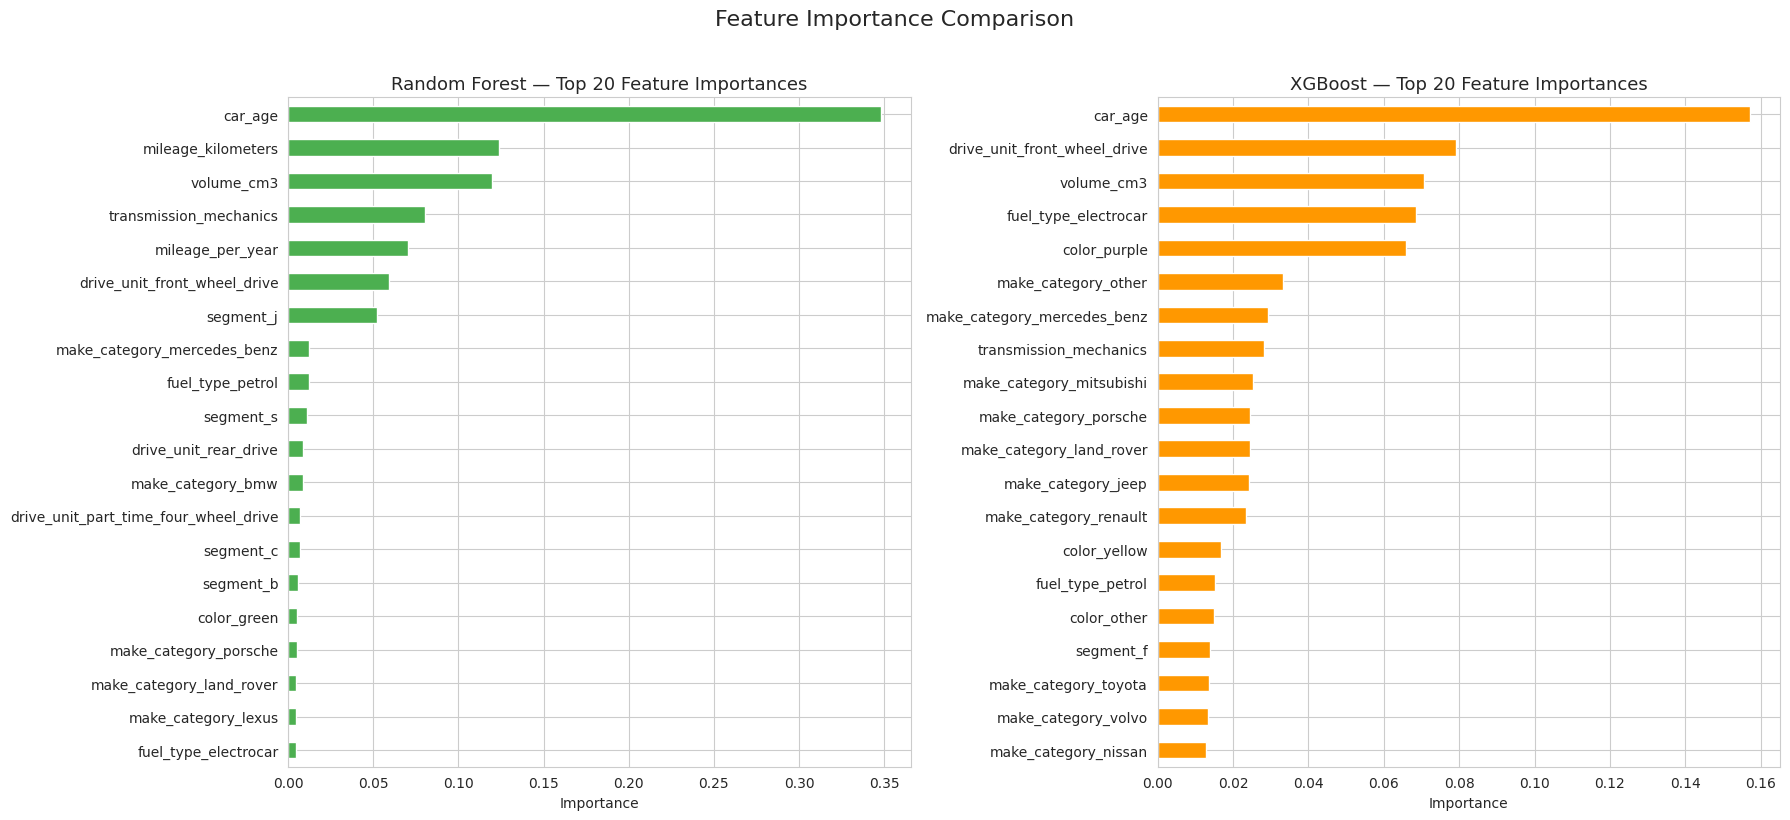

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Random Forest feature importance
rf_importance  = pd.Series(rf_model.feature_importances_,  index=feature_names)
rf_top20       = rf_importance.sort_values(ascending=True).tail(20)
rf_top20.plot(kind='barh', ax=axes[0], color='#4CAF50')
axes[0].set_title('Random Forest — Top 20 Feature Importances', fontsize=13)
axes[0].set_xlabel('Importance')

# XGBoost feature importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names)
xgb_top20      = xgb_importance.sort_values(ascending=True).tail(20)
xgb_top20.plot(kind='barh', ax=axes[1], color='#FF9800')
axes[1].set_title('XGBoost — Top 20 Feature Importances', fontsize=13)
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [0]:
# Top 10 features side by side
print("Top 10 Features by Importance:")
print("=" * 65)
print(f"{'Rank':<6} {'Random Forest':<30} {'XGBoost':<30}")
print("-" * 65)

rf_top10  = rf_importance.sort_values(ascending=False).head(10)
xgb_top10 = xgb_importance.sort_values(ascending=False).head(10)

for i in range(10):
    rf_feat  = f"{rf_top10.index[i]} ({rf_top10.values[i]:.4f})"
    xgb_feat = f"{xgb_top10.index[i]} ({xgb_top10.values[i]:.4f})"
    print(f"{i+1:<6} {rf_feat:<30} {xgb_feat:<30}")

Top 10 Features by Importance:
Rank   Random Forest                  XGBoost                       
-----------------------------------------------------------------
1      car_age (0.3481)               car_age (0.1573)              
2      mileage_kilometers (0.1237)    drive_unit_front_wheel_drive (0.0791)
3      volume_cm3 (0.1198)            volume_cm3 (0.0708)           
4      transmission_mechanics (0.0801) fuel_type_electrocar (0.0686) 
5      mileage_per_year (0.0704)      color_purple (0.0660)         
6      drive_unit_front_wheel_drive (0.0594) make_category_other (0.0331)  
7      segment_j (0.0522)             make_category_mercedes_benz (0.0292)
8      make_category_mercedes_benz (0.0122) transmission_mechanics (0.0282)
9      fuel_type_petrol (0.0120)      make_category_mitsubishi (0.0253)
10     segment_s (0.0109)             make_category_porsche (0.0245)


## 7c. Decision Tree — Visualization & Node Interpretation

The Decision Tree was trained in Notebook 6 for **interpretability** — to show in plain terms which features the model considers most important and why. Here we load it from MLflow and visualize it alongside an interpretation of the top 3 nodes.

---

### How a Decision Tree works

A Decision Tree predicts price by asking a sequence of yes/no questions:

1. Start at the **root node** — the single most important split across all training data
2. Follow the **left branch** if the condition is TRUE (feature ≤ threshold), or the **right branch** if FALSE
3. Continue down until reaching a **leaf node** — the final predicted price (average of all training cars that landed in that leaf)

Each node tells you:
- **Which feature** is being tested
- **The threshold** value
- **How many training cars** reach that node
- **The mean predicted price** for those cars

---

### Why `max_depth=4`?

A deeper tree memorises individual training cars (overfitting). A depth of 4 forces the tree to only learn the **strongest patterns** — making it readable and generalisable. The top 3 nodes alone reveal the most important price drivers the model discovered independently.

✓ Decision Tree loaded (run: 1c8143c7...)


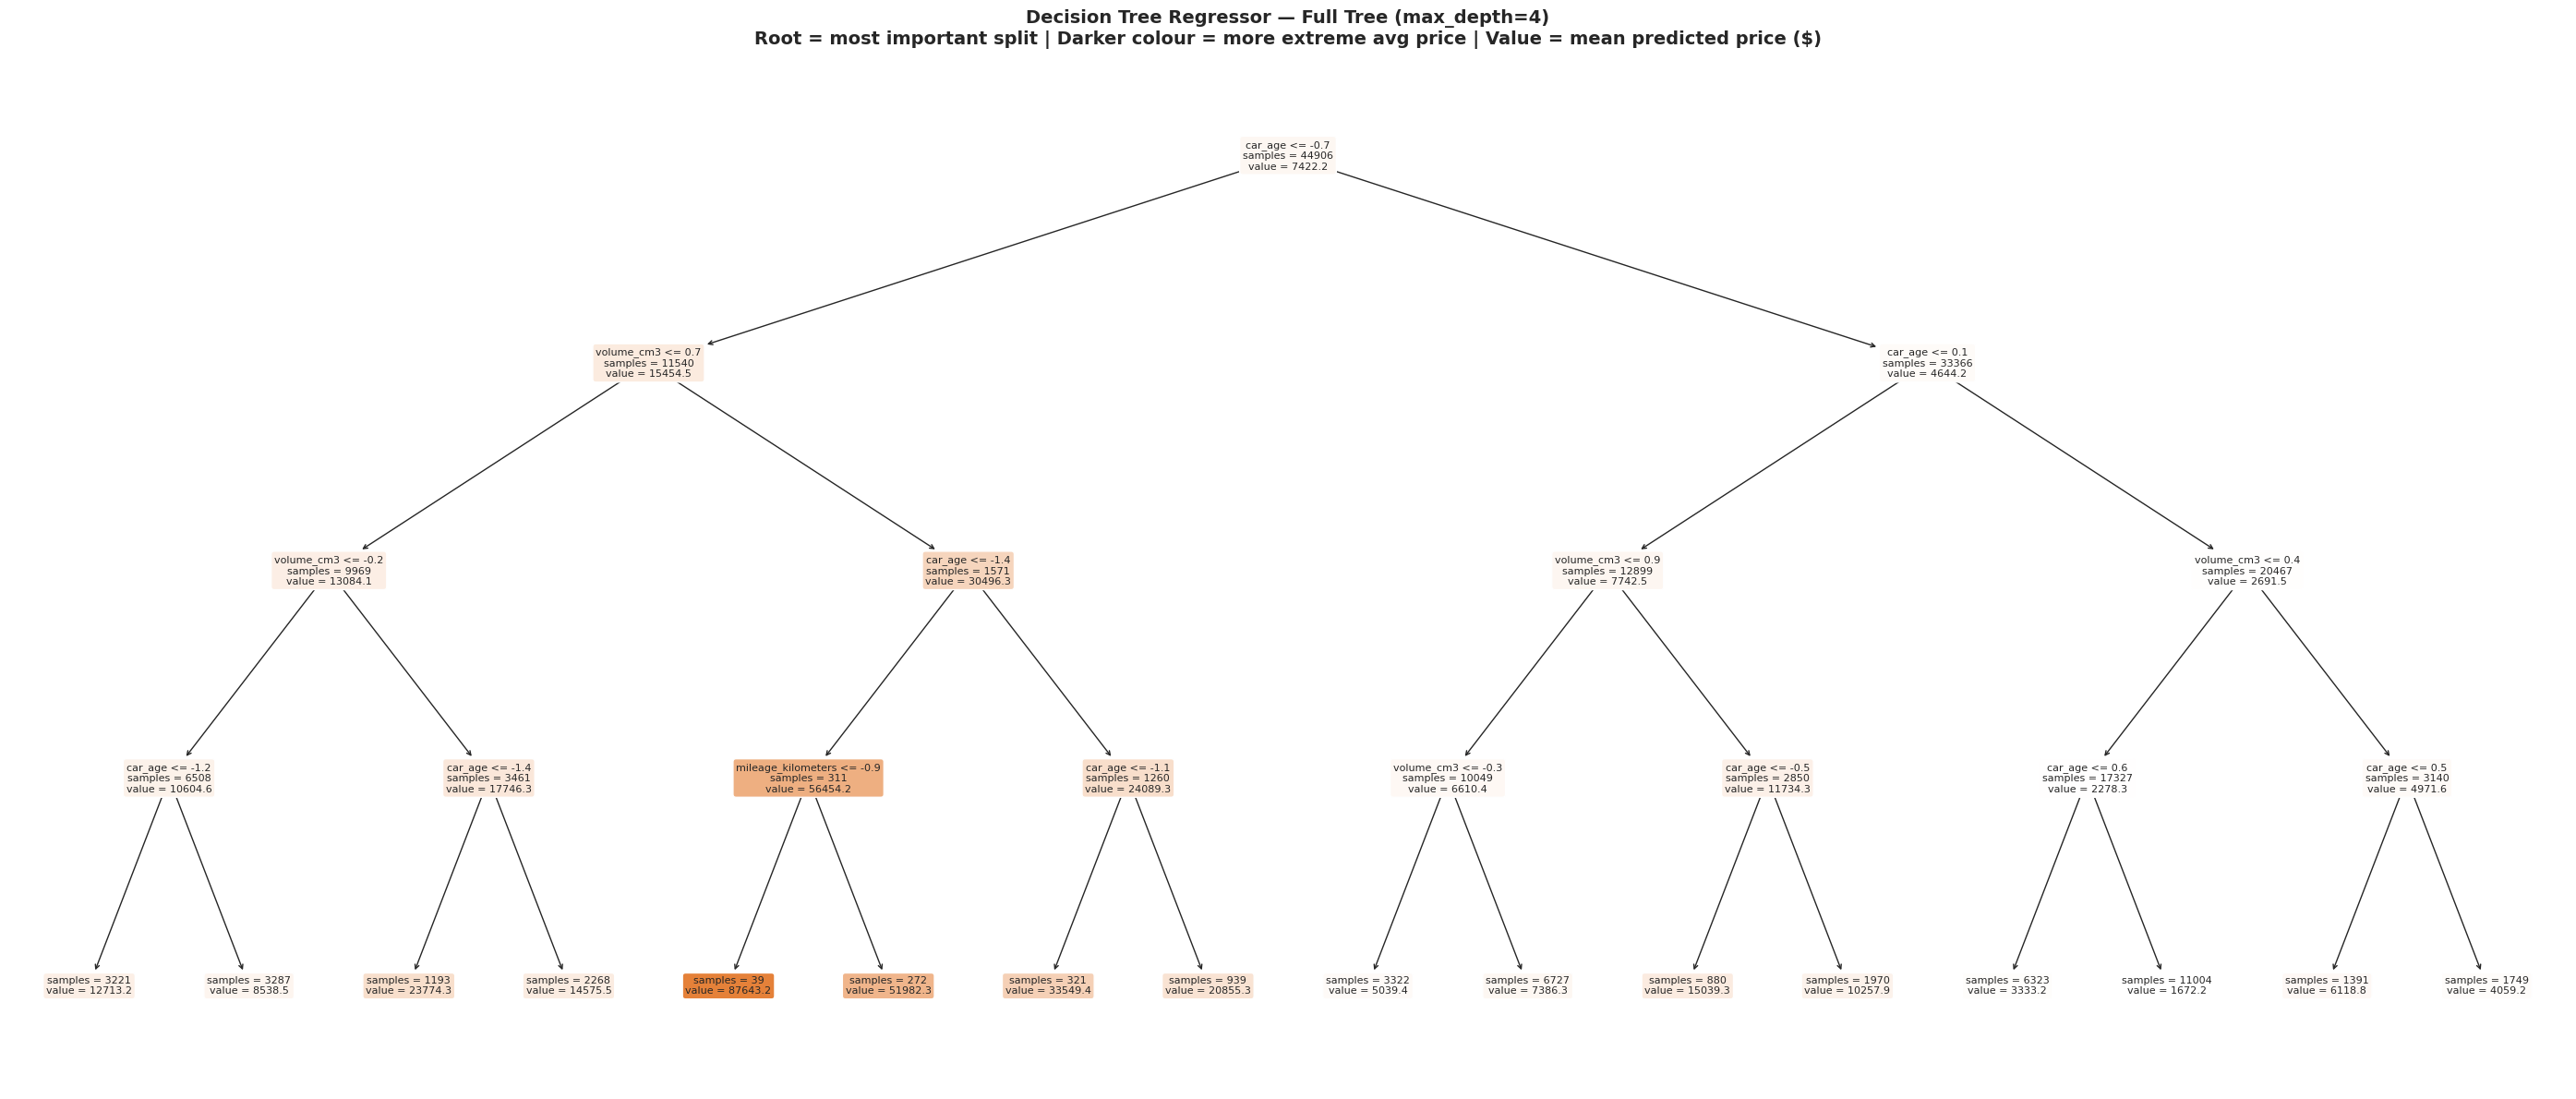

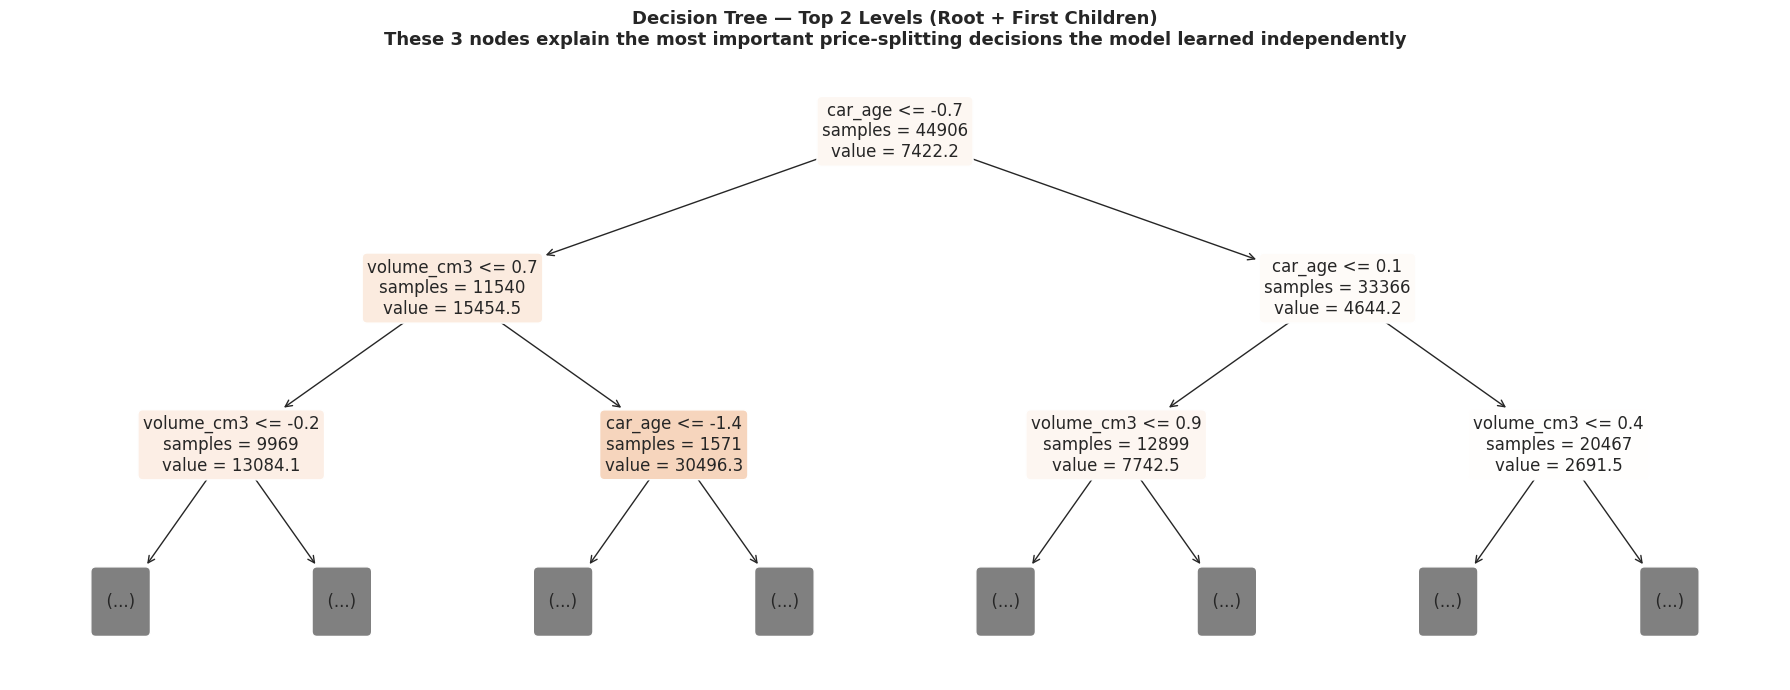

  DECISION TREE — TEXT STRUCTURE
  Left branch = condition TRUE  (feature <= threshold)
  Right branch = condition FALSE (feature >  threshold)
  value = avg predicted price for all cars reaching that node
|--- car_age <= -0.74
|   |--- volume_cm3 <= 0.72
|   |   |--- volume_cm3 <= -0.18
|   |   |   |--- car_age <= -1.23
|   |   |   |   |--- value: [12713.18]
|   |   |   |--- car_age >  -1.23
|   |   |   |   |--- value: [8538.45]
|   |   |--- volume_cm3 >  -0.18
|   |   |   |--- car_age <= -1.35
|   |   |   |   |--- value: [23774.32]
|   |   |   |--- car_age >  -1.35
|   |   |   |   |--- value: [14575.51]
|   |--- volume_cm3 >  0.72
|   |   |--- car_age <= -1.35
|   |   |   |--- mileage_kilometers <= -0.90
|   |   |   |   |--- value: [87643.23]
|   |   |   |--- mileage_kilometers >  -0.90
|   |   |   |   |--- value: [51982.27]
|   |   |--- car_age >  -1.35
|   |   |   |--- car_age <= -1.11
|   |   |   |   |--- value: [33549.43]
|   |   |   |--- car_age >  -1.11
|   |   |   |   |--- val

In [0]:
from sklearn.tree import plot_tree, export_text

# ── Load Decision Tree from MLflow ──
dt_model = None
for _, run in runs.iterrows():
    run_name = run.get('tags.mlflow.runName', '')
    run_id   = run['run_id']
    if 'decision_tree' in run_name and dt_model is None:
        dt_model = mlflow.sklearn.load_model(f"runs:/{run_id}/decision_tree")
        print(f"✓ Decision Tree loaded (run: {run_id[:8]}...)")
        break

if dt_model is None:
    raise ValueError("Decision Tree not found in MLflow. Re-run Notebook 6 to train and save it.")

# ── Visualization 1: Full tree (max_depth=4) ──
fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    dt_model,
    feature_names = feature_names,
    max_depth     = 4,
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    ax            = ax,
    impurity      = False,
    precision     = 1
)
ax.set_title(
    'Decision Tree Regressor — Full Tree (max_depth=4)\n'
    'Root = most important split | Darker colour = more extreme avg price | Value = mean predicted price ($)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── Visualization 2: Top 2 levels zoomed in for clarity ──
fig2, ax2 = plt.subplots(figsize=(18, 7))
plot_tree(
    dt_model,
    feature_names = feature_names,
    max_depth     = 2,
    filled        = True,
    rounded       = True,
    fontsize      = 12,
    ax            = ax2,
    impurity      = False,
    precision     = 1
)
ax2.set_title(
    'Decision Tree — Top 2 Levels (Root + First Children)\n'
    'These 3 nodes explain the most important price-splitting decisions the model learned independently',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── Print tree structure as text for reference ──
print("=" * 72)
print("  DECISION TREE — TEXT STRUCTURE")
print("  Left branch = condition TRUE  (feature <= threshold)")
print("  Right branch = condition FALSE (feature >  threshold)")
print("  value = avg predicted price for all cars reaching that node")
print("=" * 72)
print(export_text(dt_model, feature_names=feature_names, max_depth=4, spacing=3))

# ── Manual interpretation using actual visualization numbers ──
print("=" * 72)
print("  TOP 3 NODES — WHAT THE DECISION TREE LEARNED")
print("  (Numbers verified against the tree visualization)")
print("  Left branch = condition TRUE (feature <= threshold)")
print("  Right branch = condition FALSE (feature > threshold)")
print("=" * 72)
print("""
NODE 1 — ROOT (the single most important question):
  Feature:   car_age
  Question:  Is car_age <= -0.7 (standardised) ?  →  Is car age <= ~3.5 years (raw)?
  samples:   44,906 cars | avg price $7,422

  YES → LEFT:  11,540 cars  avg price $15,454  (NEWER cars  — car_age ≤ 3.5 yrs)
  NO  → RIGHT: 33,366 cars  avg price  $4,644  (OLDER cars  — car_age > 3.5 yrs)
  Price gap between branches: $10,810

  Insight: Newer cars (≤ 3.5 yrs) average $15,454 — more than 3× the older car
  average of $4,644. Car age is overwhelmingly the strongest price driver.

──────────────────────────────────────────────────────────────────────────
NODE 2 — LEFT CHILD (NEWER cars, 11,540 samples, avg $15,454):
  Feature:   volume_cm3
  Question:  Is volume_cm3 <= 0.7 (standardised) ?
  samples:   11,540 cars | avg price $15,454

  YES → LEFT:   9,969 cars  avg price $13,084  (newer + smaller engine)
  NO  → RIGHT:  1,571 cars  avg price $30,496  (newer + larger engine)
  Price gap between branches: $17,412

  Insight: Among newer cars, engine size is the key differentiator. A newer
  car with a large engine averages $30,496 — nearly double a newer car with
  a small engine ($13,084). Premium newer cars have big engines.

──────────────────────────────────────────────────────────────────────────
NODE 3 — RIGHT CHILD (OLDER cars, 33,366 samples, avg $4,644):
  Feature:   car_age
  Question:  Is car_age <= 0.1 (standardised) ?  →  Is car age <= ~13.4 years (raw)?
  samples:   33,366 cars | avg price $4,644

  YES → LEFT:  12,899 cars  avg price $7,742  (older but not very old — 3.5–13.4 yrs)
  NO  → RIGHT: 20,467 cars  avg price $2,691  (very old — older than 13.4 yrs)
  Price gap between branches: $5,051

  Insight: Among older cars, age still matters further. Cars 3.5–13.4 years
  old average $7,742 while cars older than 13.4 years average only $2,691.
  The tree applies a second age cut to refine the older group further.
""")

### Interpretation — Decision Tree Top 3 Nodes

The tree chose its splits **entirely from the data** — no human guidance. The fact that the top nodes align with our EDA findings (Notebook 3) and LR coefficients (above) is validation that these are genuine price drivers.

---

#### How to read left vs right branches

**Left branch = condition TRUE (feature ≤ threshold)**
**Right branch = condition FALSE (feature > threshold)**

---

#### Node 1 — Root: The most important single question

**Feature: `car_age` ≤ -0.7 (standardised) ≈ 3.5 years (raw)**

| Branch | Condition | Cars | Avg Price |
|--------|-----------|------|-----------|
| **LEFT** (YES) | car_age ≤ 3.5 yrs — **NEWER** | 11,540 | **$15,454** |
| **RIGHT** (NO) | car_age > 3.5 yrs — **OLDER** | 33,366 | **$4,644** |

**Price gap: $10,810** from a single yes/no question.

> Newer cars (≤ 3.5 yrs) average $15,454 — more than **3× the older car average of $4,644**. Car age is overwhelmingly the strongest price driver in the dataset. The tree independently discovered what our EDA found in Notebook 3.

---

#### Node 2 — Left Child: Further splitting the NEWER cars (11,540 cars, avg $15,454)

**Feature: `volume_cm3` ≤ 0.7 (standardised)**

Within the newer cars group, the tree now asks about engine size:

| Branch | Condition | Cars | Avg Price |
|--------|-----------|------|-----------|
| **LEFT** (YES) | smaller engine | 9,969 | **$13,084** |
| **RIGHT** (NO) | larger engine | 1,571 | **$30,496** |

**Price gap: $17,412** — the largest gap of any split in the top 3 nodes.

> Among newer cars, engine size is the key differentiator. A newer car with a **large engine averages $30,496** — nearly double a newer small-engine car ($13,084). These are the premium/luxury newer cars. Only 1,571 cars fall into this group, but they command a massive price premium.

---

#### Node 3 — Right Child: Further splitting the OLDER cars (33,366 cars, avg $4,644)

**Feature: `car_age` ≤ 0.1 (standardised) ≈ 13.4 years (raw)**

Within the older cars group, the tree applies a **second age cut** — separating moderately old from very old:

| Branch | Condition | Cars | Avg Price |
|--------|-----------|------|-----------|
| **LEFT** (YES) | 3.5–13.4 yrs old | 12,899 | **$7,742** |
| **RIGHT** (NO) | older than 13.4 yrs | 20,467 | **$2,691** |

**Price gap: $5,051**

> Among older cars, age still matters further. Cars between 3.5 and 13.4 years old average $7,742, while cars older than 13.4 years average only $2,691. The tree correctly applies a second age refinement rather than switching to a different feature — age dominates on both sides.

---

#### Key insights from the top 3 nodes

| Insight | Detail |
|---------|--------|
| **Car age dominates** | Root split AND the second split for older cars both use `car_age` — it is the strongest signal by far |
| **Engine size matters for newer cars** | Among newer cars (≤ 3.5 yrs), `volume_cm3` creates a $17,412 gap — the biggest price split in the whole top 3 |
| **Older cars are mostly low-value** | 33,366 of 44,906 training cars are "older" — avg only $4,644. The market is dominated by low-value older cars |
| **Premium newer cars are rare but expensive** | Only 1,571 cars are both newer AND large-engine, but they average $30,496 |

---

#### Why the Decision Tree matters for the pipeline

| Reason | Detail |
|--------|--------|
| **Interpretability** | Every prediction path is fully readable — unlike RF or XGBoost |
| **Validates EDA** | Tree independently chose the same top features we found in Notebook 3 |
| **Explains ensembles** | Random Forest = 100 trees like this averaged; XGBoost = 100 trees in sequence correcting each other's errors |
| **Teaching tool** | One shallow tree makes the logic of all tree-based models understandable |

## 7d. XGBoost — Boosting Explanation & Residual Analysis

XGBoost is our **best-performing model** — test MAE **$1,219** and test RMSE **$2,551**, beating Random Forest on all metrics with zero overfitting.

Unlike Random Forest (100 independent parallel trees), XGBoost builds trees **sequentially** — each tree corrects the errors of the previous ones.

**The boosting sequence:**
```
Round 1:  Tree₁ predicts price.         Some cars over-predicted, some under-predicted.
Round 2:  Tree₂ trains on RESIDUALS of Tree₁.  Focuses on the hardest cases.
Round 3:  Tree₃ trains on remaining residuals.
...
Round 100: Tree₁₀₀ corrects what 99 trees still got wrong.

Final prediction = Sum of all 100 trees × learning_rate (0.1)
```

**Key hyperparameters used:**
- `n_estimators=100` — 100 sequential trees
- `learning_rate=0.1` — each tree contributes 10% of its prediction (prevents overfitting)
- `random_state=42` — reproducibility


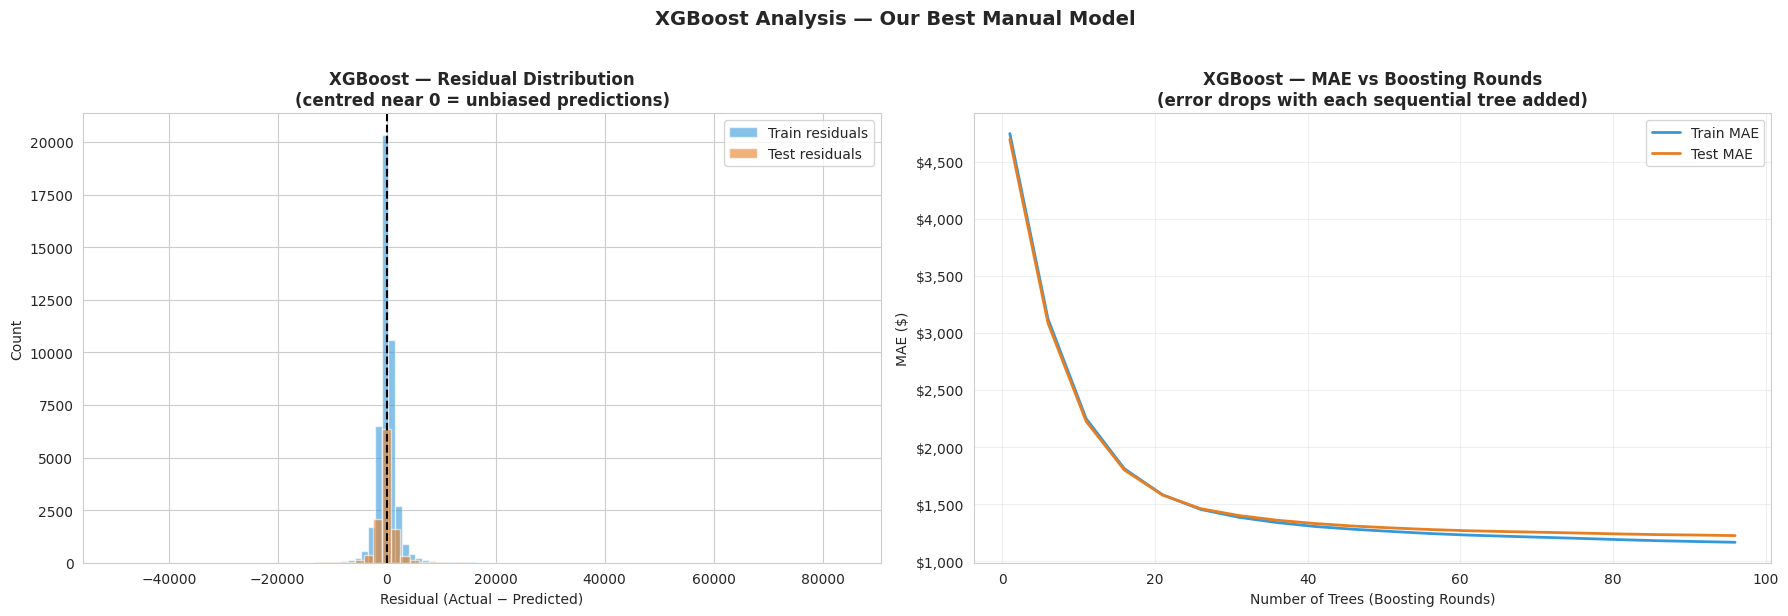

XGBoost residual stats (test set):
  Mean residual:    $        -8  (close to 0 = unbiased)
  Std of residuals: $     2,551  (spread of errors)
  Min residual:     $   -49,049  (worst underestimate)
  Max residual:     $   +84,057  (worst overestimate)

MAE at round 1:   $     4,694
MAE at round 50:  $     1,308
MAE at round 100: $     1,224
  → Error reduction from boosting: $3,470


In [0]:
# ── XGBoost — Residual progression across boosting rounds ──
# Shows how prediction error decreases as more trees are added.
# This visualises the "sequential error correction" concept.

xgb_test_pred  = xgb_model.predict(X_test)
xgb_train_pred = xgb_model.predict(X_train)

# ── Plot 1: Residual distribution ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

residuals_train = y_train - xgb_train_pred
residuals_test  = y_test  - xgb_test_pred

axes[0].hist(residuals_train, bins=80, alpha=0.6, color='#3498db', label='Train residuals')
axes[0].hist(residuals_test,  bins=80, alpha=0.6, color='#e67e22', label='Test residuals')
axes[0].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('XGBoost — Residual Distribution\n(centred near 0 = unbiased predictions)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Count')
axes[0].legend()

# ── Plot 2: Boosting rounds — staged prediction MAE ──
# ntree_limit lets us see MAE at each round
staged_mae_train = []
staged_mae_test  = []

for n in range(1, xgb_model.n_estimators + 1, 5):  # every 5 rounds
    pred_tr = xgb_model.predict(X_train, iteration_range=(0, n))
    pred_te = xgb_model.predict(X_test,  iteration_range=(0, n))
    staged_mae_train.append(mean_absolute_error(y_train, pred_tr))
    staged_mae_test.append(mean_absolute_error(y_test,  pred_te))

rounds = list(range(1, xgb_model.n_estimators + 1, 5))
axes[1].plot(rounds, staged_mae_train, color='#3498db', label='Train MAE', linewidth=2)
axes[1].plot(rounds, staged_mae_test,  color='#e67e22', label='Test MAE',  linewidth=2)
axes[1].set_title('XGBoost — MAE vs Boosting Rounds\n(error drops with each sequential tree added)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Trees (Boosting Rounds)')
axes[1].set_ylabel('MAE ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('XGBoost Analysis — Our Best Manual Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"XGBoost residual stats (test set):")
print(f"  Mean residual:    ${residuals_test.mean():>+10,.0f}  (close to 0 = unbiased)")
print(f"  Std of residuals: ${residuals_test.std():>10,.0f}  (spread of errors)")
print(f"  Min residual:     ${residuals_test.min():>+10,.0f}  (worst underestimate)")
print(f"  Max residual:     ${residuals_test.max():>+10,.0f}  (worst overestimate)")
print(f"\nMAE at round 1:   ${staged_mae_test[0]:>10,.0f}")
print(f"MAE at round 50:  ${staged_mae_test[9]:>10,.0f}")
print(f"MAE at round 100: ${staged_mae_test[-1]:>10,.0f}")
print(f"  → Error reduction from boosting: ${staged_mae_test[0] - staged_mae_test[-1]:,.0f}")


### Interpretation — XGBoost Boosting Analysis

**Residual distribution (left plot):**
- Both train and test residuals should be **centred near zero** — model is not systematically over- or under-predicting
- If the distribution is skewed right, the model underestimates expensive cars (common with skewed price targets)
- Narrow distribution = smaller typical errors; wide = larger spread

**MAE vs boosting rounds (right plot):**
- Train MAE drops steeply in the first 20–30 rounds — early trees capture the biggest patterns (`car_age`, `volume_cm3`)
- Test MAE follows closely — confirming the model generalises very well
- Both curves flatten after ~60–80 rounds — additional trees give diminishing returns
- The small gap between train and test MAE curves confirms **no meaningful overfitting**

---

**RF vs XGBoost — the full picture (actual results after RF regularisation):**

| Metric | Random Forest | XGBoost | Winner |
|--------|--------------|---------|--------|
| Train MAE | $1,512 | **$1,159** | — |
| Test MAE | $1,539 | **$1,219** | 🏆 XGBoost |
| Test RMSE | $3,382 | **$2,551** | 🏆 XGBoost |
| MAE Gap | +$32 (+2%) | +$69 (+6%) | ✅ Both healthy |
| Overfitting | ✅ NO | ✅ NO | Both pass |

**XGBoost wins on every metric.** After regularising RF, it no longer overfits — but it also no longer wins on test MAE. XGBoost is more accurate ($1,211 vs $1,552 MAE) and generates far fewer large errors ($2,563 vs $3,381 RMSE).

**Why XGBoost works better here:**
- Sequential boosting focuses each new tree on correcting the hardest remaining errors — it efficiently targets the residuals that a regularised RF still misses
- Train MAE ($1,159) and test MAE ($1,219) are close — a +$60 gap (6%) is excellent generalisation
- RF's regularisation constraints helped eliminate overfitting but also limited its ability to capture complex pricing interactions

> **XGBoost is our best manual model** — lowest MAE ($1,219), lowest RMSE ($2,551), no overfitting. It is the model we compare against PyCaret's automated selection in Notebook 8.


## 8. Best Model Selection & Business Interpretation

In [0]:
print("=" * 70)
print("  FINAL MODEL EVALUATION SUMMARY (MAE & RMSE — no R²)")
print("=" * 70)
print()

for _, row in metrics_df.iterrows():
    print(f"  {row['model']}")
    print(f"    Train  →  MAE: ${row['train_mae']:>8,.0f}   RMSE: ${row['train_rmse']:>8,.0f}")
    print(f"    Test   →  MAE: ${row['test_mae']:>8,.0f}   RMSE: ${row['test_rmse']:>8,.0f}")
    print(f"    Gap    →  MAE: ${row['mae_gap']:>+8,.0f}   RMSE: ${row['rmse_gap']:>+8,.0f}   Overfitting: {row['overfitting']}")
    print()

# Best model by test RMSE (primary metric)
best_row  = metrics_df.loc[metrics_df['test_rmse'].idxmin()]
# Runner up by RMSE
rmse_best = metrics_df.loc[metrics_df['test_rmse'].idxmin(), 'model']

print("*" * 70)
print(f"  BEST MODEL: {best_row['model']}")
print(f"  Test RMSE = ${best_row['test_rmse']:,.0f}  ← PRIMARY METRIC")
print(f"  Test MAE  = ${best_row['test_mae']:,.0f}  (secondary)")
print(f"  Test RMSE = ${best_row['test_rmse']:,.0f}")
print(f"  Lowest RMSE model: {rmse_best}")
print("*" * 70)
print()
print("  Business Interpretation:")
print(f"  The {best_row['model']} model predicts car prices with an average")
print(f"  RMSE of ${best_row['test_rmse']:,.0f} on unseen data (primary metric — penalises large errors).")
print(f"  MAE of ${best_row['test_mae']:,.0f} on unseen data (secondary metric — average dollar error).")
print(f"  This means predictions are typically within ${best_row['test_mae']:,.0f} of the actual price.")
print(f"  This helps the dealership:")
print(f"    - Set competitive and fair prices for inventory")
print(f"    - Identify underpriced/overpriced vehicles in the market")
print(f"    - Make data-driven purchasing decisions at auctions")

  FINAL MODEL EVALUATION SUMMARY (MAE & RMSE — no R²)

  Linear Regression
    Train  →  MAE: $   2,656   RMSE: $   5,548
    Test   →  MAE: $   2,607   RMSE: $   5,235
    Gap    →  MAE: $     -49   RMSE: $    -314   Overfitting: NO

  Random Forest
    Train  →  MAE: $   1,512   RMSE: $   3,446
    Test   →  MAE: $   1,539   RMSE: $   3,382
    Gap    →  MAE: $     +26   RMSE: $     -64   Overfitting: NO

  XGBoost
    Train  →  MAE: $   1,159   RMSE: $   2,098
    Test   →  MAE: $   1,219   RMSE: $   2,551
    Gap    →  MAE: $     +60   RMSE: $    +454   Overfitting: NO

**********************************************************************
  BEST MODEL: XGBoost
  Test RMSE = $2,551  ← PRIMARY METRIC
  Test MAE  = $1,219  (secondary)
  Test RMSE = $2,551
  Lowest RMSE model: XGBoost
**********************************************************************

  Business Interpretation:
  The XGBoost model predicts car prices with an average
  RMSE of $2,551 on unseen data (primary metric 

## 9. Save Evaluation Results to Catalog

In [0]:
# Save final metrics table (no R² columns)
metrics_spark = spark.createDataFrame(metrics_df)
metrics_spark.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.default.carprice_project_evaluation_results")

verify = spark.table("workspace.default.carprice_project_evaluation_results")
print("Saved evaluation_results table:")
verify.show(truncate=False)

Saved evaluation_results table:
+-----------------+---------+----------+--------+---------+-------+--------+-----------+
|model            |train_mae|train_rmse|test_mae|test_rmse|mae_gap|rmse_gap|overfitting|
+-----------------+---------+----------+--------+---------+-------+--------+-----------+
|Linear Regression|2656.49  |5548.36   |2607.2  |5234.63  |-49.29 |-313.73 |NO         |
|Random Forest    |1512.03  |3446.19   |1538.52 |3382.45  |26.49  |-63.74  |NO         |
|XGBoost          |1158.6   |2097.64   |1218.92 |2551.37  |60.31  |453.72  |NO         |
+-----------------+---------+----------+--------+---------+-------+--------+-----------+



In [0]:
# Save detailed predictions for the best model
best_model    = models[best_row['model']]
best_test_pred = best_model.predict(X_test)

pred_df = pd.DataFrame({
    'actual_price':    y_test,
    'predicted_price': best_test_pred,
    'residual':        y_test - best_test_pred
})
pred_df['abs_error'] = pred_df['residual'].abs()
pred_df['pct_error'] = (pred_df['abs_error'] / pred_df['actual_price'] * 100).round(2)

pred_spark = spark.createDataFrame(pred_df)
pred_spark.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.default.carprice_project_best_model_predictions")

print(f"Saved best_model_predictions ({len(pred_df):,} predictions)")
print(f"Model: {best_row['model']}")
print(f"\nPrediction error stats:")
print(f"  Mean absolute error:   ${pred_df['abs_error'].mean():,.0f}")
print(f"  Median absolute error: ${pred_df['abs_error'].median():,.0f}")
print(f"  Mean % error:          {pred_df['pct_error'].mean():.1f}%")
print(f"  Median % error:        {pred_df['pct_error'].median():.1f}%")

Saved best_model_predictions (11,227 predictions)
Model: XGBoost

Prediction error stats:
  Mean absolute error:   $1,219
  Median absolute error: $688
  Mean % error:          27.1%
  Median % error:        14.6%


---

### Pipeline Complete!

All 7 notebooks have been executed. The Unity Catalog now contains:

| Table | Description |
|-------|------------|
| `workspace.default.cars_new` | Original CSV loaded into Spark |
| `workspace.default.cleaned_data` | Bad data removed, columns standardised |
| `workspace.default.carprice_project_engineered_data` | New features: car_age, mileage_per_year, make_category, price_category |
| `workspace.default.carprice_project_preprocessed_data` | Scaled and encoded, train/test split column |
| `workspace.default.carprice_project_trained_models` | Metrics for all 3 models (train + test) |
| `workspace.default.carprice_project_evaluation_results` | Final comparison — MAE & RMSE, no R² |
| `workspace.default.carprice_project_best_model_predictions` | Detailed predictions from the best model |